In [ ]:
# NOTE: NOTEBOOK PARAMETERS
'''
    - selected_model : str - it is the name of the ML model used for the TC Detection
    - setup : str - the name of the setup used for training
    - tracking_type: str (default: None) - it is the optional name of the ByteTrack tracking configuration

'''
selected_model = 'localization_model-classification_model'
setup = 'cls_loc_models'
tracking_type = 'TT0.7-TB3-MT0.8-BB21'
remove_above_x_lat = 30
remove_land = False

our_work_name = 'ByteStorm'

# years and months on which we compare the results
years = [i for i in range(2020, 2024)]
months = [1,2,3,4,5,6,7,8,9,10,11,12]

# lat and lon ranges of the domain
lon_range = [100, 320]
lat_range = [0, 70]

# minimum number of consecutive detection at 6h lead time to consider the track true
min_track_count = 12

# info
remove_atlantic = True
remove_short_tracks = True

# maximum distance to consider true the match
max_track_distance_matching = 300.0

# whether to store the figures or not
save_figures = True

# output file extention
file_ext = 'pdf'

In [ ]:
from cartopy.mpl.ticker import (LongitudeFormatter, LatitudeFormatter)
import matplotlib.transforms as transforms
import matplotlib.ticker as mticker
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import cartopy.feature as cf
import cartopy.crs as ccrs

import pandas as pd
import numpy as np
import os
import sys

sys.path.append('../resources/library/tropical_cyclone')
from tropical_cyclone.cyclone import (
    filter_basin, 
    filter_tracks, 
    compute_pod_and_far, 
    signif, 
    plot_pod_and_far, 
    remove_tcs_above_x_lat, 
    remove_tcs_originated_on_land, 
    plot_tracks, 
)
import dynamicopy

import warnings
warnings.filterwarnings('ignore')

%load_ext autoreload
%autoreload 2

In [ ]:
# main dirs
data_src = 'PATH-TO/data'
bourdin_trackers_src = 'PATH-TO/zenodo_bourdin/trackers'
inference_src = os.path.join(data_src, 'inference')

# trackers source
ibtracs_src = os.path.join(data_src, 'ibtracs', 'filtered', 'ibtracs_main-tracks_6h_1980-2023_TS-NR-ET-MX-SS-DS.csv')
owz_src = os.path.join(bourdin_trackers_src, 'OWZ', 'tracks', 'ERA5_OWZ.csv')
track_src = os.path.join(bourdin_trackers_src, 'TRACK', 'ERA5_TRACK.csv')
uz_src = os.path.join(bourdin_trackers_src, 'UZ', 'tracks', 'ERA5_UZ.csv')
cnrm_src = os.path.join(bourdin_trackers_src, 'CNRM', 'tracks_vor15_res5_t1_pt-1_pw5_rel25.csv')

# our model
if tracking_type is not None:
    hybrid_ml_tracker_src = os.path.join(data_src, f'inference/{setup}/{selected_model}/tracking_{tracking_type}.csv')
else:
    hybrid_ml_tracker_src = os.path.join(data_src, f'inference/{setup}/{selected_model}/tracking.csv')

# directory to store images
out_dir = f'./images/{setup}/2020-2023_{selected_model}'
if tracking_type is not None:
    out_dir += f'-{tracking_type}'
if remove_above_x_lat is not None:
    out_dir += f'-NOLAT{remove_above_x_lat}'
if remove_land:
    out_dir += f'-NOLAND'

In [4]:
os.makedirs(out_dir, exist_ok=True)

In [5]:
ibtracs = pd.read_csv(ibtracs_src, index_col=0).rename(columns={'ISO_TIME':'time','LAT':'lat','LON':'lon','SID':'track_id','BASIN':'basin'})[['time','lat','lon','track_id','basin','NATURE','WMO_WIND']]
owz = pd.read_csv(owz_src).rename(columns={' year':'year', ' month':'month', ' day':'day', ' hour':'hour',' lon':'lon',' lat':'lat'})
track = pd.read_csv(track_src, index_col=0)
uz = pd.read_csv(uz_src).rename(columns={' year':'year', ' month':'month', ' day':'day', ' hour':'hour',' lon':'lon',' lat':'lat'})
cnrm = pd.read_csv(cnrm_src).rename(columns={'Longitude':'lon', 'Latitude':'lat', 'Date':'time', 'ID':'track_id'})
hybrid = pd.read_csv(hybrid_ml_tracker_src, index_col=0).rename(columns={'ISO_TIME':'time', 'LAT':'lat', 'LON':'lon', 'WS':'ws', 'TRACK_ID':'track_id', 'HAVERSINE':'haversine'})

# convert iso timed to pandas datetime format
ibtracs['time'] = pd.to_datetime(ibtracs['time'])
owz['time'] = pd.to_datetime(owz[['year','month','day','hour']])
track['time'] = pd.to_datetime(track['time'])
uz['time'] = pd.to_datetime(uz[['year','month','day','hour']])
cnrm['time'] = pd.to_datetime(cnrm['time'])
hybrid['time'] = pd.to_datetime(hybrid['time'])

# drop duplicates
hybrid = hybrid.drop_duplicates()

In [6]:
# update the basin name of the storm
ibtracs.loc[ibtracs['basin']=='WP', 'basin'] = 'WNP'
ibtracs.loc[ibtracs['basin']=='EP', 'basin'] = 'ENP'

In [7]:
# separate ENP and WNP basins
ibtracs = filter_basin(ibtracs)
owz = filter_basin(owz)
track = filter_basin(track)
uz = filter_basin(uz)
cnrm = filter_basin(cnrm)
hybrid = filter_basin(hybrid)

In [8]:
# get intersection of all dates to be sure that each timesteps has been seen by EVERY tracker
dates_df = pd.read_csv(os.path.join(inference_src, 'new_dates.csv'))
dates = pd.to_datetime(dates_df['dates'].to_numpy())
# get only dates within the test set years
dates = pd.to_datetime([date for date in dates if date.year in years and date.month in months])

In [9]:
# filter the tracks according to the procedure
ibtracs = filter_tracks(ibtracs, dates, lat_range, lon_range, min_track_count, remove_atlantic, remove_short_tracks)
owz = filter_tracks(owz, dates, lat_range, lon_range, min_track_count, remove_atlantic, remove_short_tracks)
track = filter_tracks(track, dates, lat_range, lon_range, min_track_count, remove_atlantic, remove_short_tracks)
uz = filter_tracks(uz, dates, lat_range, lon_range, min_track_count, remove_atlantic, remove_short_tracks)
cnrm = filter_tracks(cnrm, dates, lat_range, lon_range, min_track_count, remove_atlantic, remove_short_tracks)
hybrid = filter_tracks(hybrid, dates, lat_range, lon_range, min_track_count, remove_atlantic, remove_short_tracks)

In [10]:
print(len(hybrid))
if remove_above_x_lat is not None:
    print(f'removing above {remove_above_x_lat} LAT')
    hybrid = remove_tcs_above_x_lat(hybrid, remove_above_x_lat)
    print(len(hybrid))
if remove_land:
    print(f'removing land')
    hybrid = remove_tcs_originated_on_land(hybrid)
    print(len(hybrid))

5204
removing above 30 LAT
4822


# Dynamicopy Track Matching

In [11]:
hybrid_matches, hybrid_res = compute_pod_and_far(dynamicopy, hybrid, our_work_name, ibtracs, max_track_distance_matching, print_results=False)

In [12]:
# algo_results = pd.concat([owz_res, track_res, uz_res, cnrm_res, hybrid_res]).reset_index(drop=True)
algo_results = pd.concat([hybrid_res]).reset_index(drop=True)
algo_results['model'] = selected_model
algo_results['pod'] = algo_results['pod'] * 100
algo_results['far'] = algo_results['far'] * 100
algo_results

,algo,hits,misses,false alarms,pod,far,model
0,BYTESTORM,142,20,40,87.654321,21.978022,02_vgg_v3_loc_vo_850_msl-02_vgg_v3_cls_vo_850_msl


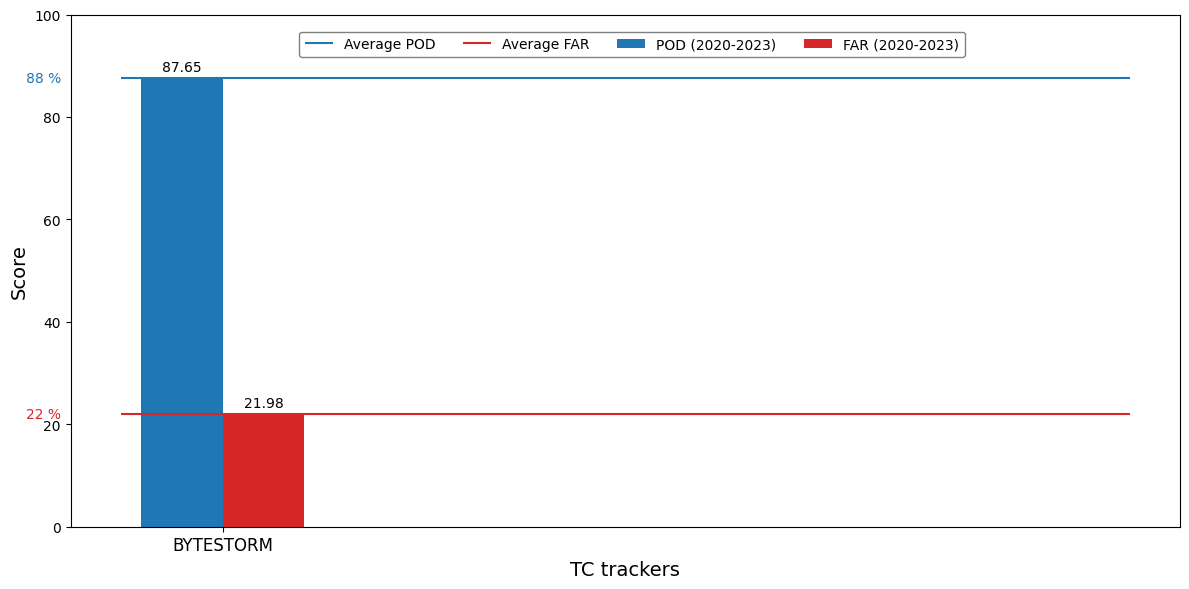

In [13]:
outfile = os.path.join(out_dir, f'pod_far.{file_ext}') if save_figures else None
plot_pod_and_far(algo_results, label=f' ({years[0]}-{years[-1]})', outfile=outfile)

In [14]:
# get trackers by ENP basin
ibtracs_enp = ibtracs[ibtracs['basin']=='ENP']
hybrid_enp = hybrid[hybrid['basin']=='ENP']

# get trackers by WNP basin
ibtracs_wnp = ibtracs[ibtracs['basin']=='WNP']
hybrid_wnp = hybrid[hybrid['basin']=='WNP']

# compute the POD and FAR for ENP basin
hybrid_matches_enp, hybrid_res_enp = compute_pod_and_far(dynamicopy, hybrid_enp, our_work_name, ibtracs_enp, max_track_distance_matching, print_results=False)

# algo_results_enp = pd.concat([owz_res_enp, track_res_enp, uz_res_enp, cnrm_res_enp, hybrid_res_enp]).reset_index(drop=True)
algo_results_enp = pd.concat([hybrid_res_enp]).reset_index(drop=True)
algo_results_enp['model'] = selected_model
algo_results_enp['pod'] = algo_results_enp['pod'] * 100
algo_results_enp['far'] = algo_results_enp['far'] * 100

# compute the POD and FAR for WNP basin
hybrid_matches_wnp, hybrid_res_wnp = compute_pod_and_far(dynamicopy, hybrid_wnp, our_work_name, ibtracs_wnp, max_track_distance_matching, print_results=False)

# algo_results_wnp = pd.concat([owz_res_wnp, track_res_wnp, uz_res_wnp, cnrm_res_wnp, hybrid_res_wnp]).reset_index(drop=True)
algo_results_wnp = pd.concat([hybrid_res_wnp]).reset_index(drop=True)
algo_results_wnp['model'] = selected_model
algo_results_wnp['pod'] = algo_results_wnp['pod'] * 100
algo_results_wnp['far'] = algo_results_wnp['far'] * 100


In [15]:
def plot_pod_and_far_v2(algo_results: pd.DataFrame, label, ax = None, sharex = False, outfile = None):
    x = np.arange(len(algo_results))  # the label locations
    width = 0.4  # the width of the bars
    multiplier = 0

    base_ax = ax
    if base_ax is None:
        fig, ax = plt.subplots(layout='constrained', figsize=(12,6))
    
    # add horizontal mean
    ax.hlines(y=algo_results['pod'].mean(), xmin=-0.3, xmax=4.65, zorder=0, color='tab:blue', label='Average POD', linestyles='dashed')
    
    ax.hlines(y=algo_results['far'].mean(), xmin=-0.3, xmax=4.65, zorder=0, color='tab:red', label='Average FAR', linestyles='dashed')
    
    offset = width * multiplier
    rects = ax.bar(x + offset, np.round(algo_results['pod'],2), width, label=f'POD' + label, color='tab:blue')
    ax.bar_label(rects, padding=3)
    multiplier += 1
    
    offset = width * multiplier
    rects = ax.bar(x + offset, np.round(algo_results['far'],2), width, label=f'FAR' + label, color='tab:red')
    ax.bar_label(rects, padding=3)
    multiplier += 1
    
    # Add some text for labels, title and custom x-axis tick labels, etc.
    ax.set_ylabel('Score', size = 14)
    ax.set_ylim(0, 100)
    
    if not sharex:
        # add the x labels
        ax.set_xlabel('TC trackers', size = 14)
        ax.set_xticks(x + width/2, algo_results['algo'], fontsize=12)
        # add the legend
        box = ax.get_position()
        ax.set_position([box.x0, box.y0, box.width, box.height])
        ax.legend(loc='upper left', markerscale=10, edgecolor='gray', framealpha=1, ncol=4, bbox_to_anchor=(0.13 , -0.17))
    else:
        if base_ax is None:
            # add the x labels
            ax.set_xlabel('TC trackers', size = 14)
            ax.set_xticks(x + width/2, algo_results['algo'], fontsize=12)
            # add the legend
            box = ax.get_position()
            ax.set_position([box.x0, box.y0, box.width, box.height])
            ax.legend(loc='upper left', markerscale=10, edgecolor='gray', framealpha=1, ncol=4, bbox_to_anchor=(0.2 , 0.98))
    plt.tight_layout()
    if base_ax is not None:
        return
    
    if outfile:
        plt.savefig(outfile, dpi=300)
    else:
        plt.show()


In [16]:
algo_results_enp['basin'] = 'ENP'
algo_results_wnp['basin'] = 'WNP'
algo_results_basins = pd.concat([algo_results_enp, algo_results_wnp]).reset_index(drop=True)
algo_results_basins

,algo,hits,misses,false alarms,pod,far,model,basin
0,BYTESTORM,61,7,17,89.705882,21.794872,02_vgg_v3_loc_vo_850_msl-02_vgg_v3_cls_vo_850_msl,ENP
1,BYTESTORM,81,13,23,86.170213,22.115385,02_vgg_v3_loc_vo_850_msl-02_vgg_v3_cls_vo_850_msl,WNP


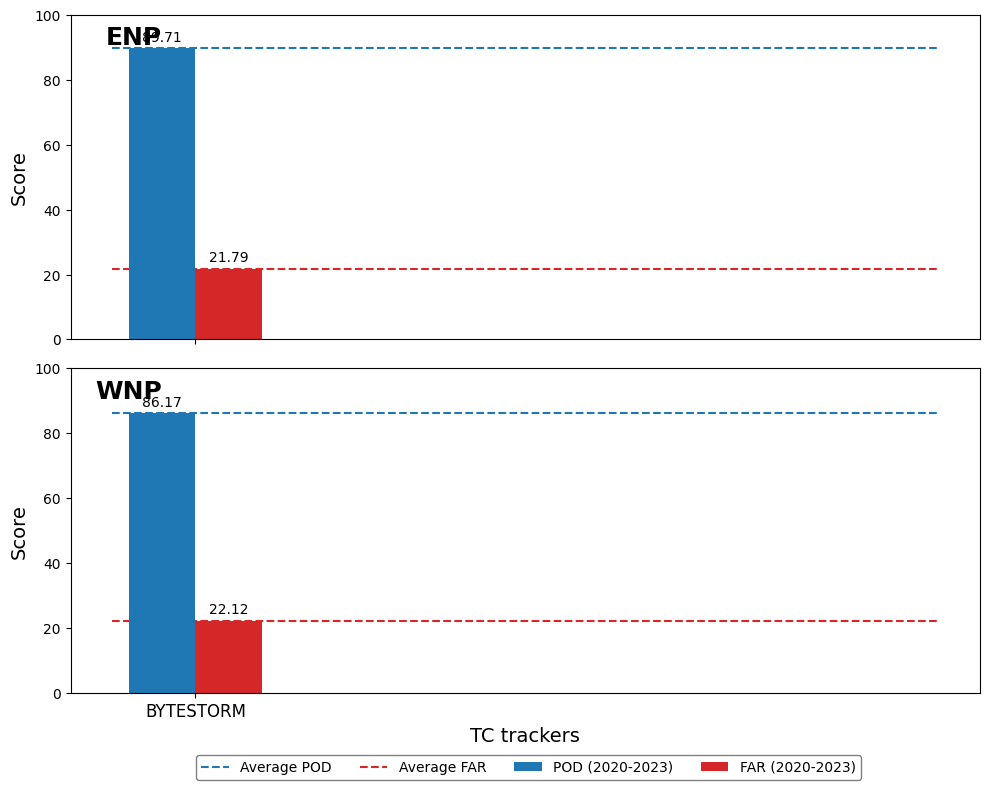

In [17]:
fig, ax = plt.subplots(2, 1, layout='constrained', figsize=(10, 8), sharex = True)
plot_pod_and_far_v2(algo_results_enp, label=f' ({years[0]}-{years[-1]})', ax = ax[0], sharex = True, outfile=None)
plot_pod_and_far_v2(algo_results_wnp, label=f' ({years[0]}-{years[-1]})', ax = ax[1], sharex = False, outfile=None)
ax[0].text(0.0, 93, 'ENP', fontsize=18, weight='bold', color='black', ha='right', va='center')
ax[1].text(0.0, 93, 'WNP', fontsize=18, weight='bold', color='black', ha='right', va='center')
plt.tight_layout()
outfile = os.path.join(out_dir, f'pod_far_enp_wnp.{file_ext}') if save_figures else None
if outfile:
    plt.savefig(outfile, dpi=300)
else:
    plt.show()

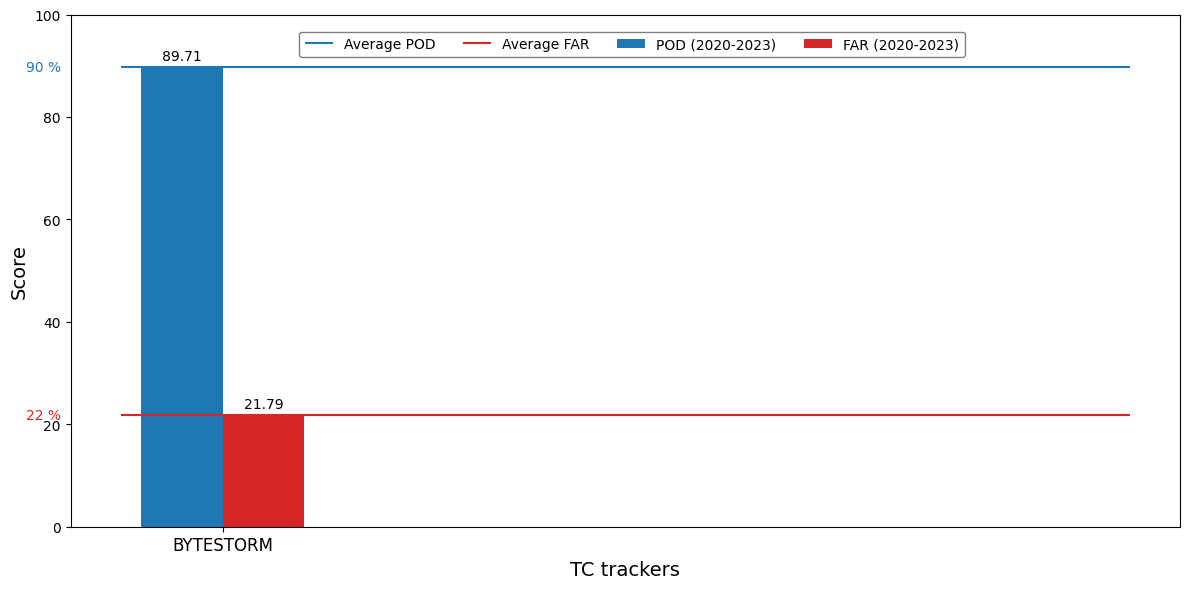

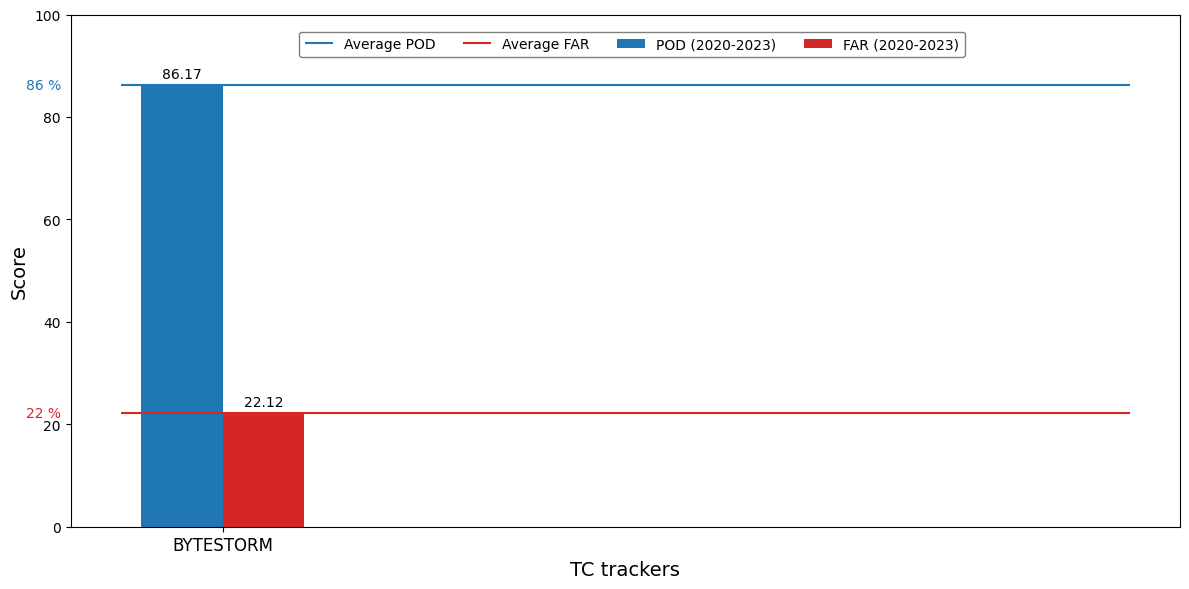

In [18]:
outfile = os.path.join(out_dir, f'pod_far_ENP.{file_ext}') if save_figures else None
plot_pod_and_far(algo_results_enp, label=f' ({years[0]}-{years[-1]})', outfile=outfile)

outfile = os.path.join(out_dir, f'pod_far_WNP.{file_ext}') if save_figures else None
plot_pod_and_far(algo_results_wnp, label=f' ({years[0]}-{years[-1]})', outfile=outfile)

# Top 5 Longest Tracks Comparison

In [19]:
longest_ibtracs_track_ids = ibtracs.value_counts('track_id')[:5].reset_index()['track_id'].to_numpy()
ibtracs_longest_tracks = ibtracs[ibtracs['track_id'].isin(longest_ibtracs_track_ids)]
longest_ibtracs_track_ids

array(['2021219N08193', '2023213N14257', '2023207N09141', '2023138N05151',
       '2020277N21141'], dtype=object)

In [20]:
ibtracs_longest_tracks.NATURE.unique()

array(['DS', 'MX', 'TS', 'ET'], dtype=object)

In [21]:
# get only TS storms
ibtracs_longest_tracks = ibtracs_longest_tracks[ibtracs_longest_tracks['NATURE'].isin(['TS', 'ET'])]

In [22]:
hybrid_matches_lts, hybrid_res_lts = compute_pod_and_far(dynamicopy, hybrid, our_work_name, ibtracs_longest_tracks, max_track_distance_matching, print_results=False)

In [23]:
hybrid_matches_lts = pd.merge(hybrid_matches_lts, ibtracs_longest_tracks.rename(columns={'track_id': 'id_ibtracs'}).value_counts('id_ibtracs').reset_index(), on='id_ibtracs')

In [24]:
# load original ibtracs
ori_ibtracs = pd.read_csv(ibtracs_src, index_col=0).rename(columns={'ISO_TIME':'time','LAT':'lat','LON':'lon','SID':'track_id'})[['time','lat','lon','track_id','NATURE','WMO_WIND','NAME']]

In [25]:
# find the track ids and the corresponding name
track_id_and_name = pd.DataFrame({
    'track_id': longest_ibtracs_track_ids, 
    'name': [ori_ibtracs[ori_ibtracs['track_id']==tid].iloc[0]['NAME'] for tid in longest_ibtracs_track_ids] 
})
track_id_and_name

,track_id,name
0,2021219N08193,OMAIS
1,2023213N14257,DORA
2,2023207N09141,KHANUN
3,2023138N05151,MAWAR
4,2020277N21141,CHAN-HOM


In [26]:
hybrid_matches_lts = pd.merge(hybrid_matches_lts, track_id_and_name.rename(columns={'track_id':'id_ibtracs'}), on='id_ibtracs')

In [27]:
hybrid_matches_lts['perc'] = (hybrid_matches_lts['matching_timesteps'] / hybrid_matches_lts['count']) * 100

# drop duplicates
hybrid_matches_lts = hybrid_matches_lts.drop_duplicates('id_ibtracs')

In [28]:
track_id_and_name

,track_id,name
0,2021219N08193,OMAIS
1,2023213N14257,DORA
2,2023207N09141,KHANUN
3,2023138N05151,MAWAR
4,2020277N21141,CHAN-HOM


In [29]:
ibtracs_longest_tracks.rename(columns={'track_id': 'id_ibtracs'}).value_counts('id_ibtracs').reset_index()

,id_ibtracs,count
0,2023213N14257,64
1,2023138N05151,61
2,2021219N08193,60
3,2023207N09141,57
4,2020277N21141,41


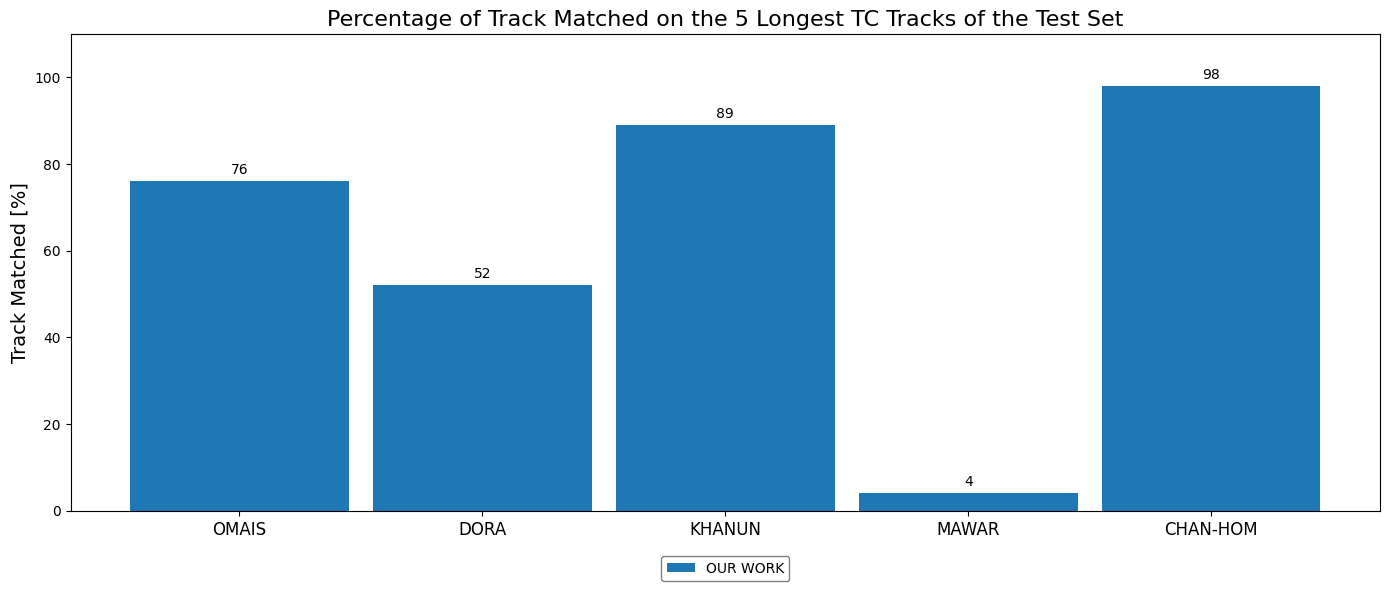

In [31]:
fig, ax = plt.subplots(1, 1, figsize=(14, 6))
x = np.arange(len(longest_ibtracs_track_ids))
width = 0.9

rects = ax.bar(x, [np.around(val, 0) for val in hybrid_matches_lts['perc'].to_numpy()], width, label=f'OUR WORK')
ax.bar_label(rects, padding=3)


ax.set_xticks(x)
ax.set_xticklabels(
    [track_id_and_name[track_id_and_name['track_id']==track_id]['name'].to_numpy()[0] for track_id in longest_ibtracs_track_ids], 
    fontdict = {
        'size': 12, 
    }
)
ax.set_ylabel(
    'Track Matched [%]', 
    size = 14, 
)
ax.set_ylim(0, 110)

# add the legend
box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width, box.height])
ax.legend(loc='upper center', markerscale=10, edgecolor='gray', framealpha=1, ncol=5, bbox_to_anchor=(0.5, -0.08))

plt.title(
    'Percentage of Track Matched on the 5 Longest TC Tracks of the Test Set', 
    fontdict = {
        'size':16, 
    }
)
plt.tight_layout()

outfile = os.path.join(out_dir, f'top_5_longest_tracks_bar.{file_ext}') if save_figures else None
plt.savefig(outfile, dpi=300) if save_figures else plt.show()

In [33]:
hybrid_lts_track_id = hybrid_matches_lts[hybrid_matches_lts['id_ibtracs']==longest_ibtracs_track_ids[0]][f'id_{our_work_name}'].iloc[0]
total_number_of_detections = len(hybrid[hybrid['track_id']==hybrid_lts_track_id])
number_of_matching_timesteps = int(hybrid_matches_lts[hybrid_matches_lts['id_ibtracs']==longest_ibtracs_track_ids[0]]['matching_timesteps'].iloc[0])
total_number_of_observations = int(hybrid_matches_lts[hybrid_matches_lts['id_ibtracs']==longest_ibtracs_track_ids[0]]['count'].iloc[0])
number_of_matching_timesteps, total_number_of_observations, total_number_of_detections

(31, 60, 56)

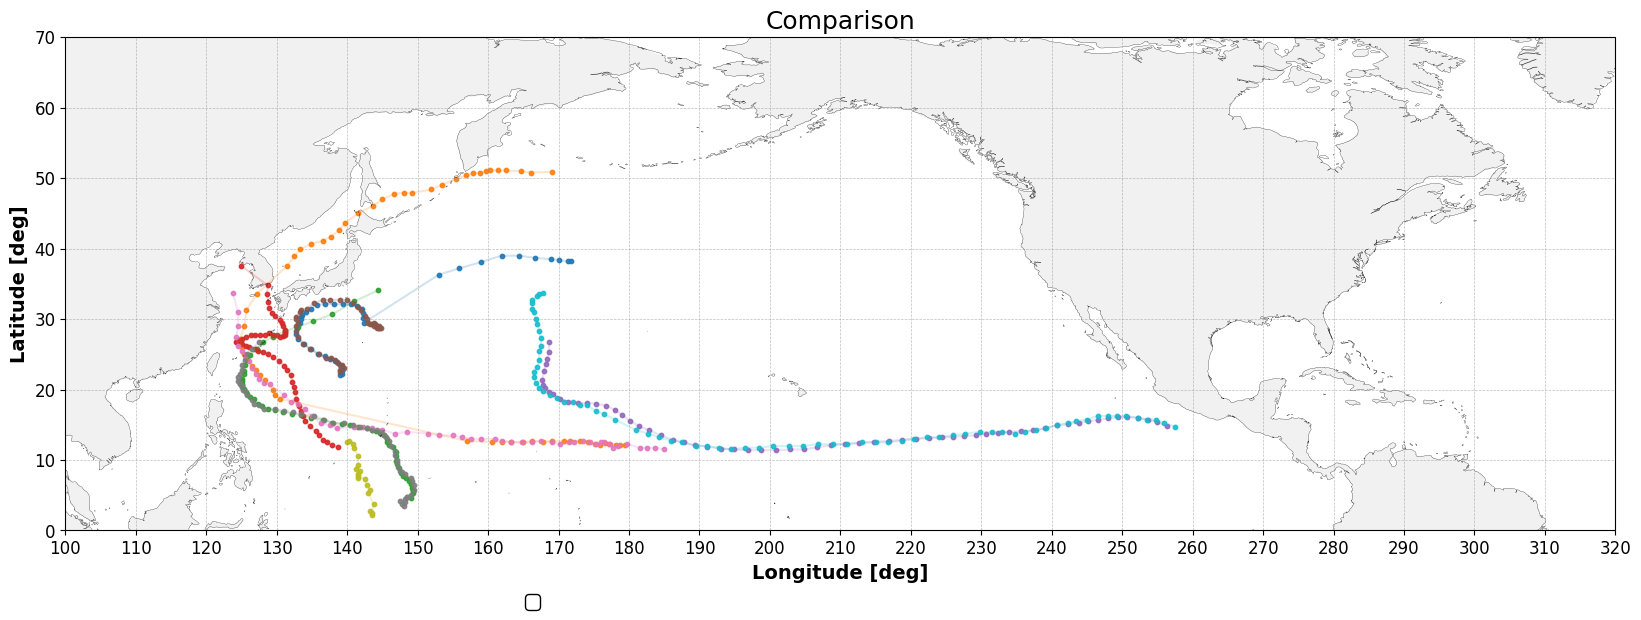

In [34]:
hybrid_longest_tracks = hybrid[hybrid['track_id'].isin(hybrid_matches_lts['id_'+our_work_name].unique())]

ibtracs_longest_tracks['lon'] = ibtracs_longest_tracks['lon'] % 360
hybrid_longest_tracks['lon'] = hybrid_longest_tracks['lon'] % 360

title = 'Comparison'

# set map extent
central_longitude = (lon_range[1] - lon_range[0])

fig = plt.figure(figsize=(25,10))
proj = ccrs.PlateCarree(central_longitude=central_longitude)
ax = plt.axes(projection=proj)

image_extent = [lon_range[0], lon_range[1], lat_range[0], lat_range[1]]
ax.set_extent(image_extent, crs=ccrs.PlateCarree())
ax.coastlines(resolution='50m', lw=0.2)
ax.add_feature(cf.LAND, facecolor='lightgrey', alpha=0.3)

fontdict = {'weight':'bold', 'size':14}
title_fontdict = {'size':18}
ticksize = 12
track_id_col = 'TRACK_ID' if 'TRACK_ID' in ibtracs_longest_tracks.columns else 'track_id'
lon_col = 'LON' if 'LON' in ibtracs_longest_tracks.columns else 'lon'
lat_col = 'LAT' if 'LAT' in ibtracs_longest_tracks.columns else 'lat'

# plot tracks in each basin
alpha = 0.5
marker_size = 10.0
transform = ccrs.PlateCarree()
plt.title(title, fontsize = 18)

for tracker in [
        ibtracs_longest_tracks, 
        hybrid_longest_tracks, 
    ]:
    for i, id in enumerate(tracker[track_id_col].unique()):
        ax.plot(tracker[tracker[track_id_col]==id][lon_col], tracker[tracker[track_id_col]==id][lat_col], alpha=0.2, transform=transform)
        ax.scatter(tracker[tracker[track_id_col]==id][lon_col], tracker[tracker[track_id_col]==id][lat_col], s=marker_size, marker='o', alpha=0.9, transform=transform, label=f'' if i==0 else None)

# x-axis
longitudes = np.arange(lon_range[0], lon_range[1]+1, 10)
lon_formatter = LongitudeFormatter(zero_direction_label=False)
ax.xaxis.set_major_formatter(lon_formatter)
ax.xaxis.set_major_locator(mticker.FixedLocator(longitudes-central_longitude))
ax.set_xticklabels(longitudes, size=ticksize)
ax.set_xticks(longitudes-central_longitude)
ax.set_xlabel('Longitude [deg]', fontdict=fontdict)

# y-axis
latitudes = np.arange(lat_range[0], lat_range[1]+1, 10)
lat_formatter = LatitudeFormatter()
ax.yaxis.set_major_formatter(lat_formatter)
ax.yaxis.set_major_locator(mticker.FixedLocator(latitudes))
ax.set_yticklabels(latitudes, size=ticksize)
ax.set_yticks(latitudes)
ax.set_ylabel('Latitude [deg]', fontdict=fontdict)

# gridlines
gl = ax.gridlines(crs=proj, draw_labels=False, dms=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.xlocator = mticker.FixedLocator(longitudes-central_longitude)
gl.ylocator = mticker.FixedLocator(latitudes)
gl.xlines = True
gl.ylines = True

box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
ax.legend(loc='upper left', markerscale=2., edgecolor='black', framealpha=1, ncol=4, fontsize=14, bbox_to_anchor=(0.29,-0.11))

# if outfile: 
#     plt.savefig(f'{outfile}', dpi=300, bbox_inches='tight')
plt.show()

In [35]:
ibtracs_ = pd.read_csv(ibtracs_src, index_col=0).rename(columns={'ISO_TIME':'time','LAT':'lat','LON':'lon','SID':'track_id'})
ibtracs_['time'] = pd.to_datetime(ibtracs_['time'])
ibtracs_ = filter_tracks(ibtracs_, dates, lat_range, lon_range, min_track_count, True, True)
ibtracs_

,track_id,SEASON,NUMBER,BASIN,SUBBASIN,NAME,time,NATURE,lat,lon,...,BOM_GUST_PER,REUNION_GUST,REUNION_GUST_PER,USA_SEAHGT,USA_SEARAD_NE,USA_SEARAD_SE,USA_SEARAD_SW,USA_SEARAD_NW,STORM_SPEED,STORM_DIR
0,2020129N07134,2020,24,WP,MM,VONGFONG,2020-05-08 06:00:00,MX,7.0,134.0,...,,,,,,,,,3,235
1,2020129N07134,2020,24,WP,MM,VONGFONG,2020-05-08 12:00:00,MX,6.8,133.7,...,,,,,,,,,5,240
2,2020129N07134,2020,24,WP,MM,VONGFONG,2020-05-08 18:00:00,MX,6.6,133.2,...,,,,,,,,,4,245
3,2020129N07134,2020,24,WP,MM,VONGFONG,2020-05-09 00:00:00,MX,6.5,132.9,...,,,,,,,,,3,280
4,2020129N07134,2020,24,WP,MM,VONGFONG,2020-05-09 06:00:00,MX,6.6,132.6,...,,,,,,,,,4,305
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5154,2023349N04141,2023,88,WP,MM,JELAWAT,2023-12-17 18:00:00,TS,7.2,127.6,...,,,,,,,,,9,275
5155,2023349N04141,2023,88,WP,MM,JELAWAT,2023-12-18 00:00:00,TS,7.3,126.7,...,,,,,,,,,9,275
5156,2023349N04141,2023,88,WP,MM,JELAWAT,2023-12-18 06:00:00,TS,7.4,126.0,...,,,,,,,,,3,270
5157,2023349N04141,2023,88,WP,MM,JELAWAT,2023-12-18 12:00:00,MX,7.3,125.8,...,,,,,,,,,4,285


In [36]:
def apply_nan(value):
    if value == ' ':
        return np.nan
    else:
        return float(value)
other_columns = ['time','lat','lon','track_id','NATURE']
wind_columns = [
    'WMO_WIND', # MSW from the WNO agency
    'USA_WIND', # MSW in knots
    'TOKYO_WIND', # MSW [10-min averaging period]
    'CMA_WIND', # MSW [2-min averaging period]
    'HKO_WIND', # NO INFO
    # 'NEWDELHI_WIND', 
    # 'REUNION_WIND', 
    # 'BOM_WIND', # 
    # 'NADI_WIND', 
    # 'WELLINGTON_WIND', 
    # 'DS824_WIND', 
    'TD9636_WIND', # Estimated highest wind speed at the time indicated. These estimates are subjective and must be interpreted with caution
    # 'TD9635_WIND', 
    # 'NEUMANN_WIND', 
    # 'MLC_WIND', 
]
for col in wind_columns:
    ibtracs_[col] = ibtracs_[col].apply(apply_nan)

# ibtracs_ = ibtracs_[(ibtracs_['track_id'].isin(longest_ibtracs_track_ids)) & (ibtracs_['NATURE']=='TS')][
ibtracs_ = ibtracs_[(ibtracs_['track_id'].isin(longest_ibtracs_track_ids))][
    other_columns + wind_columns]
ibtracs_['TOKYO_WIND'] = ibtracs_['TOKYO_WIND'] * 0.88
ibtracs_['CMA_WIND'] = ibtracs_['CMA_WIND'] * 0.88
ibtracs_['HKO_WIND'] = ibtracs_['HKO_WIND'] * 0.88
ibtracs_['TD9636_WIND'] = ibtracs_['TD9636_WIND'] * 0.88

# ibtracs_ = pd.merge(ibtracs_, ibtracs_longest_tracks, on=['time', 'lat', 'lon', 'track_id', 'NATURE'])
ibtracs_

,time,lat,lon,track_id,NATURE,WMO_WIND,USA_WIND,TOKYO_WIND,CMA_WIND,HKO_WIND,TD9636_WIND
773,2020-10-03 06:00:00,21.0,140.9,2020277N21141,DS,NaN,10.0,NaN,NaN,NaN,NaN
774,2020-10-03 12:00:00,21.1,140.8,2020277N21141,DS,NaN,10.0,NaN,NaN,NaN,NaN
775,2020-10-03 18:00:00,21.6,140.4,2020277N21141,MX,NaN,15.0,NaN,22.00,NaN,NaN
776,2020-10-04 00:00:00,21.7,140.2,2020277N21141,MX,NaN,15.0,NaN,22.00,NaN,NaN
777,2020-10-04 06:00:00,21.8,139.9,2020277N21141,MX,NaN,20.0,NaN,25.52,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
4329,2023-08-21 06:00:00,33.6,175.8,2023213N14257,MX,NaN,NaN,NaN,16.72,NaN,NaN
4330,2023-08-21 12:00:00,34.3,177.0,2023213N14257,MX,NaN,NaN,NaN,22.00,NaN,NaN
4331,2023-08-21 18:00:00,35.3,178.3,2023213N14257,MX,NaN,NaN,NaN,22.00,NaN,NaN
4332,2023-08-22 00:00:00,36.2,179.6,2023213N14257,MX,NaN,NaN,NaN,22.00,NaN,NaN


In [37]:
from haversine import haversine_vector

In [38]:
def plot_distributions_by_track_id(algos, track_id, tc_name, matches, tracks, ibtracs, outfile=None):
    _, ax = plt.subplots(1, 1, figsize=(13,4))
    plt.title(f'{tc_name} Distance/MSW track distribution', fontdict={'size':12, 'weight':'bold'})
    for algo, match, track in zip(algos, matches, tracks):
        tc_track_id = match[match['id_ibtracs']==track_id]['id_'+algo].iloc[0]
        tc_tracks = track[track['track_id'] == tc_track_id]
        tc_tracks['sid'] = track_id
        ibtracs['sid'] = ibtracs['track_id']
        tc_tracks_merge = pd.merge(tc_tracks, ibtracs, on=['time', 'sid'])
        tc_tracks_merge['dist'] = haversine_vector(
            tc_tracks_merge[['lat_x', 'lon_x']].to_numpy(), 
            tc_tracks_merge[['lat_y', 'lon_y']].to_numpy(), 
            normalize = True, 
            )
        tc_tracks_merge
        plt.scatter(tc_tracks_merge['WMO_WIND'], tc_tracks_merge['dist'], label=f'{algo.upper()}')
    plt.xlabel('MSW [knots]')
    plt.ylabel('Distance [km]')
    plt.yscale('log')
    
    box = ax.get_position()
    ax.set_position([box.x0, box.y0, box.width, box.height])
    ax.legend(loc='upper left', markerscale=1, edgecolor='gray', framealpha=1, ncol=5, bbox_to_anchor=(0.23, 1.0))
    if outfile is not None:
        plt.savefig(outfile, dpi=300)
    else:
        plt.show()

In [39]:
pd.merge(ibtracs_.value_counts('track_id').reset_index(), track_id_and_name, on='track_id')

,track_id,count,name
0,2021219N08193,95,OMAIS
1,2023213N14257,88,DORA
2,2023138N05151,67,MAWAR
3,2023207N09141,67,KHANUN
4,2020277N21141,65,CHAN-HOM


# Track Durations

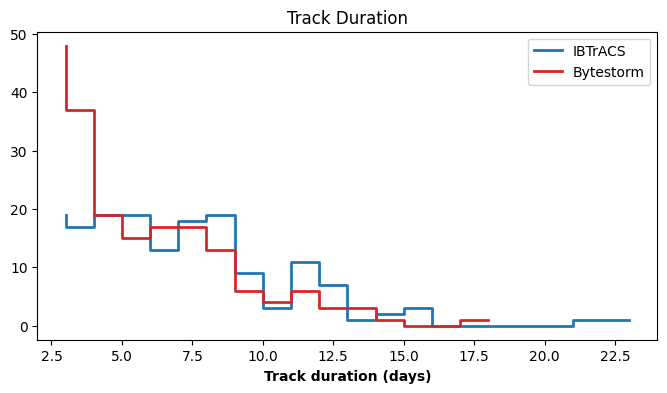

In [40]:
plt.figure(figsize=(8,4))

ibtracs_track_durations = ibtracs.track_id.value_counts().to_numpy()//4
bins = (ibtracs_track_durations).max()
freq_x, bin_edges_x = np.histogram(ibtracs_track_durations, bins=bins, range=(3,bins+3))
plt.plot(bin_edges_x[:-3], freq_x[:-2], label='IBTrACS', drawstyle='steps', linewidth=2.0, color='tab:blue')

hybrid_track_durations = hybrid.track_id.value_counts().to_numpy()//4
bins = (hybrid_track_durations).max()
freq_x, bin_edges_x = np.histogram(hybrid_track_durations, bins=bins, range=(3,bins+3))
plt.plot(bin_edges_x[:-3], freq_x[:-2], label=our_work_name.capitalize(), drawstyle='steps', linewidth=2.0, color='tab:red')

plt.xlabel('Track duration (days)', fontdict={'weight':'bold'})
plt.title(f'Track Duration')
plt.legend()

plt.savefig(os.path.join(out_dir, f'track_duration_days.{file_ext}'), dpi=300) if save_figures else plt.show()

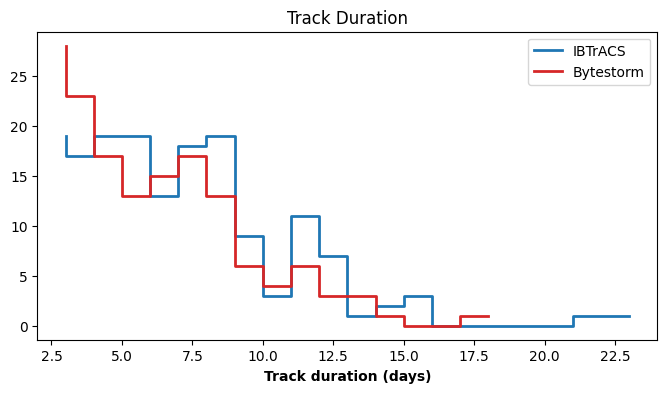

In [41]:
plt.figure(figsize=(8,4))

ibtracs_track_durations = ibtracs.track_id.value_counts().to_numpy()//4
bins = (ibtracs_track_durations).max()
freq_x, bin_edges_x = np.histogram(ibtracs_track_durations, bins=bins, range=(3,bins+3))
plt.plot(bin_edges_x[:-3], freq_x[:-2], label='IBTrACS', drawstyle='steps', linewidth=2.0, color='tab:blue')

hybrid_track_durations = hybrid[hybrid['track_id'].isin(hybrid_matches['id_'+our_work_name].unique())].track_id.value_counts().to_numpy()//4
bins = (hybrid_track_durations).max()
freq_x, bin_edges_x = np.histogram(hybrid_track_durations, bins=bins, range=(3,bins+3))
plt.plot(bin_edges_x[:-3], freq_x[:-2], label=our_work_name.capitalize(), drawstyle='steps', linewidth=2.0, color='tab:red')

plt.xlabel('Track duration (days)', fontdict={'weight':'bold'})
plt.title(f'Track Duration')
plt.legend()

plt.savefig(os.path.join(out_dir, f'track_duration_days_on_matched_tcs.{file_ext}'), dpi=300) if save_figures else plt.show()

# Seasonality

Plot number of TC tracks for every month of year

- Maybe create a plot for each Tracker
- Maybe add only False Alarms and Hits (as Bourdin)

In [42]:
for month in ibtracs.time.dt.month.unique():
    print(len(ibtracs[ibtracs['time'].dt.month == month].track_id.unique()))

7
16
28
50
37
37
15
5
1
5
1


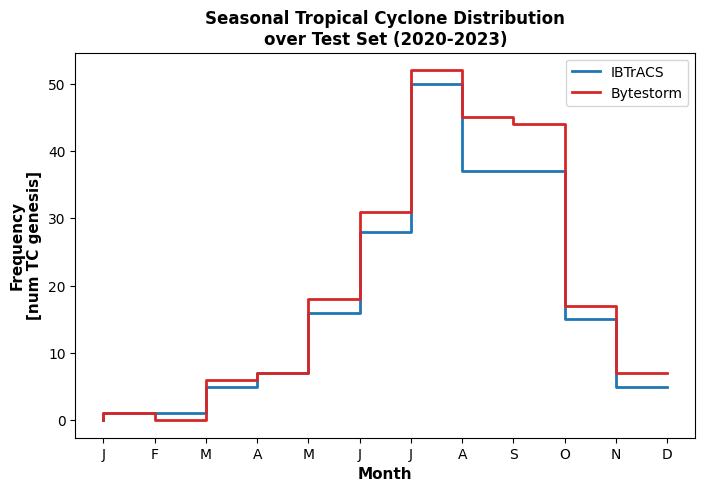

In [43]:
fig, ax = plt.subplots(figsize=(8, 5))

plt.plot(np.arange(len(months)), [len(ibtracs[ibtracs['time'].dt.month == month].track_id.unique()) for month in months], label='IBTrACS', drawstyle='steps', linewidth=2.0, color='tab:blue')
plt.plot(np.arange(len(months)), [len(hybrid[hybrid['time'].dt.month == month].track_id.unique()) for month in months], label=our_work_name.capitalize(), drawstyle='steps', linewidth=2.0, color='tab:red')

plt.xlabel('Month', fontdict={'weight':'bold', 'size':11})
plt.ylabel('Frequency\n[num TC genesis]', fontdict={'weight':'bold', 'size':11})
# ax.set_yticks([])
ax.set_xticks(np.arange(0, 12, 1))
ax.set_xticklabels(['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D'])
plt.title(f'Seasonal Tropical Cyclone Distribution\nover Test Set ({years[0]}-{years[-1]})', fontdict={'weight':'bold', 'size':12})
plt.legend()

plt.savefig(os.path.join(out_dir, f'seasonal_tc_dist.{file_ext}'), dpi=300) if save_figures else plt.show()

# Interannual Variability

Plot the number of TC tracks for every year

In [44]:
# compute interannual variabilities
ibtracs['year'] = ibtracs['time'].dt.year
hybrid['year'] = hybrid['time'].dt.year

years_df = pd.DataFrame(data={'year':years})

ibtracs_iav_enp = pd.merge(ibtracs[ibtracs['basin']=='ENP'].groupby(by='year')['track_id'].unique().apply(len).reset_index(), years_df, on='year', how='right').fillna(0)['track_id'].to_numpy()
hybrid_iav_enp = pd.merge(hybrid[hybrid['basin']=='ENP'].groupby(by='year')['track_id'].unique().apply(len).reset_index(), years_df, on='year', how='right').fillna(0)['track_id'].to_numpy()

ibtracs_iav_wnp = pd.merge(ibtracs[ibtracs['basin']=='WNP'].groupby(by='year')['track_id'].unique().apply(len).reset_index(), years_df, on='year', how='right').fillna(0)['track_id'].to_numpy()
hybrid_iav_wnp = pd.merge(hybrid[hybrid['basin']=='WNP'].groupby(by='year')['track_id'].unique().apply(len).reset_index(), years_df, on='year', how='right').fillna(0)['track_id'].to_numpy()

In [45]:
ibtracs_iav_enp_pearsonr = pearsonr(ibtracs_iav_enp, ibtracs_iav_enp)
hybrid_iav_enp_pearsonr = pearsonr(ibtracs_iav_enp, hybrid_iav_enp)

ibtracs_iav_enp_pearsonr_round = np.round(ibtracs_iav_enp_pearsonr.statistic, 2)
hybrid_iav_enp_pearsonr_round = np.round(hybrid_iav_enp_pearsonr.statistic, 2)

ibtracs_iav_enp_pearsonr_signif = signif(ibtracs_iav_enp_pearsonr.pvalue, 2)
hybrid_iav_enp_pearsonr_signif = signif(hybrid_iav_enp_pearsonr.pvalue, 2)

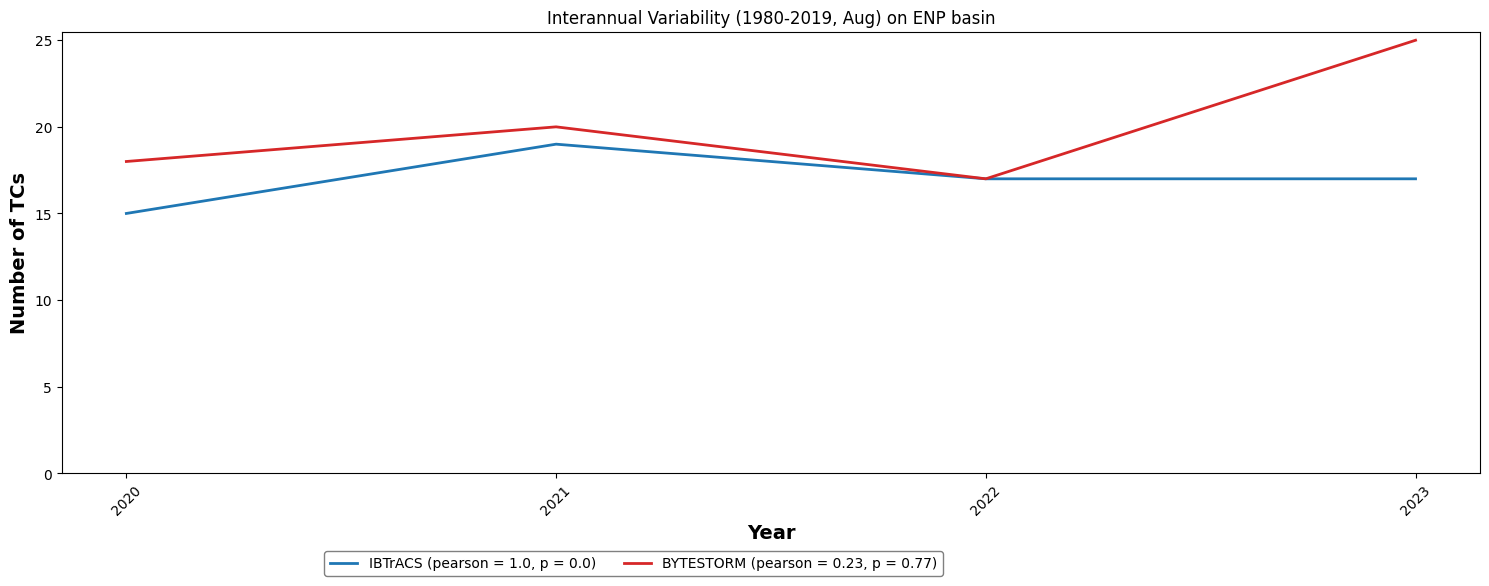

In [46]:
fig, ax = plt.subplots(figsize=(15,6))

plt.title(f'Interannual Variability (1980-2019, Aug) on ENP basin')
plt.plot(np.arange(len(years)), ibtracs_iav_enp, label=f'IBTrACS (pearson = {ibtracs_iav_enp_pearsonr_round}, p = {ibtracs_iav_enp_pearsonr_signif})', linewidth=2.0, color='tab:blue')
plt.plot(np.arange(len(years)), hybrid_iav_enp, label=f'{our_work_name.upper()} (pearson = {hybrid_iav_enp_pearsonr_round}, p = {hybrid_iav_enp_pearsonr_signif})', linewidth=2.0, color='tab:red')

ax.set_xticks(np.arange(len(years)))
ax.set_xticklabels(years, rotation=45)

ax.set_xlabel('Year', fontdict={'weight':'bold', 'size':'14'})
ax.set_ylabel('Number of TCs', fontdict={'weight':'bold', 'size':'14'})

plt.ylim(0, None)

box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width, box.height])
ax.legend(loc='upper left', markerscale=8, edgecolor='gray', framealpha=1, ncol=3, bbox_to_anchor=(0.18 ,-0.16))

plt.tight_layout()
plt.savefig(os.path.join(out_dir, f'interannual_variability_enp_basin.{file_ext}'), dpi=300) if save_figures else plt.show()

In [47]:
ibtracs_iav_wnp_pearsonr = pearsonr(ibtracs_iav_wnp, ibtracs_iav_wnp)
hybrid_iav_wnp_pearsonr = pearsonr(ibtracs_iav_wnp, hybrid_iav_wnp)

ibtracs_iav_wnp_pearsonr_round = np.round(ibtracs_iav_wnp_pearsonr.statistic, 2)
hybrid_iav_wnp_pearsonr_round = np.round(hybrid_iav_wnp_pearsonr.statistic, 2)

ibtracs_iav_wnp_pearsonr_signif = signif(ibtracs_iav_wnp_pearsonr.pvalue, 2)
hybrid_iav_wnp_pearsonr_signif = signif(hybrid_iav_wnp_pearsonr.pvalue, 2)

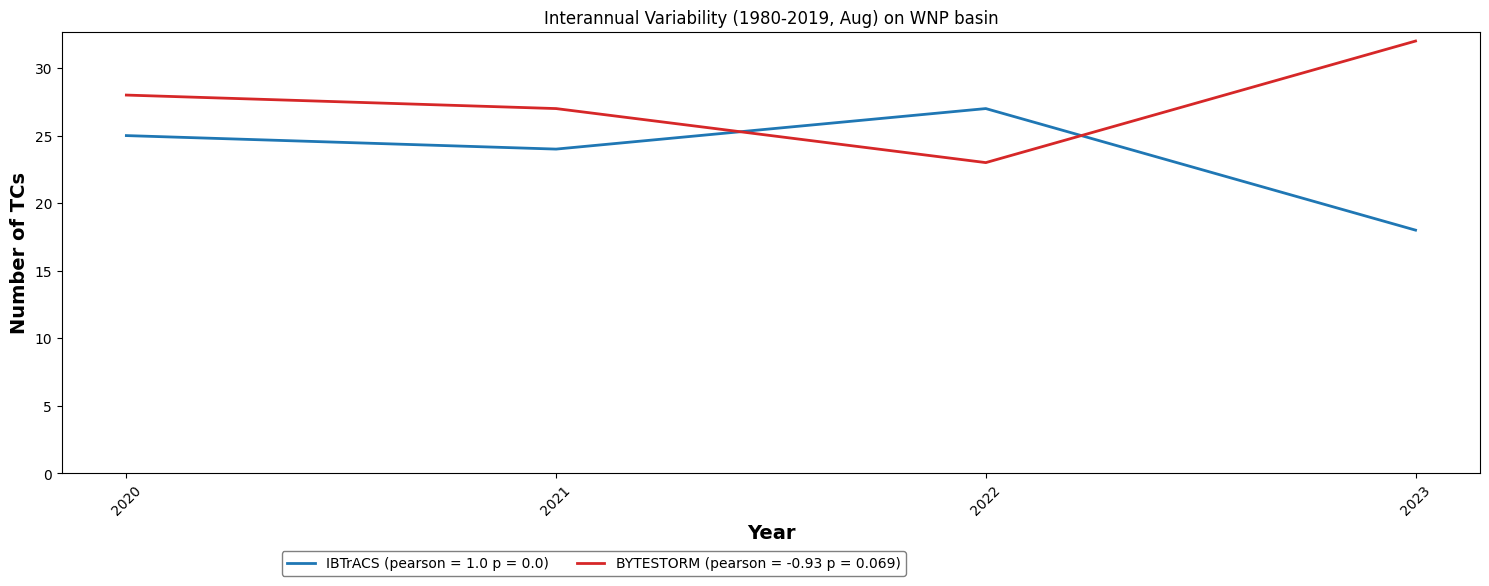

In [48]:
fig, ax = plt.subplots(figsize=(15,6))

plt.title(f'Interannual Variability (1980-2019, Aug) on WNP basin')

plt.plot(np.arange(len(years)), ibtracs_iav_wnp, label=f'IBTrACS (pearson = {ibtracs_iav_wnp_pearsonr_round} p = {ibtracs_iav_wnp_pearsonr_signif})', linewidth=2.0, color='tab:blue')
plt.plot(np.arange(len(years)), hybrid_iav_wnp, label=f'{our_work_name.upper()} (pearson = {hybrid_iav_wnp_pearsonr_round} p = {hybrid_iav_wnp_pearsonr_signif})', linewidth=2.0, color='tab:red')

ax.set_xticks(np.arange(len(years)))
ax.set_xticklabels(years, rotation=45)

ax.set_xlabel('Year', fontdict={'weight':'bold', 'size':'14'})
ax.set_ylabel('Number of TCs', fontdict={'weight':'bold', 'size':'14'})

plt.ylim(0, None)

box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width, box.height])
ax.legend(loc='upper left', markerscale=8, edgecolor='gray', framealpha=1, ncol=3, bbox_to_anchor=(0.15 ,-0.16))

plt.tight_layout()
plt.savefig(os.path.join(out_dir, f'interannual_variability_wnp_basin.{file_ext}'), dpi=300) if save_figures else plt.show()

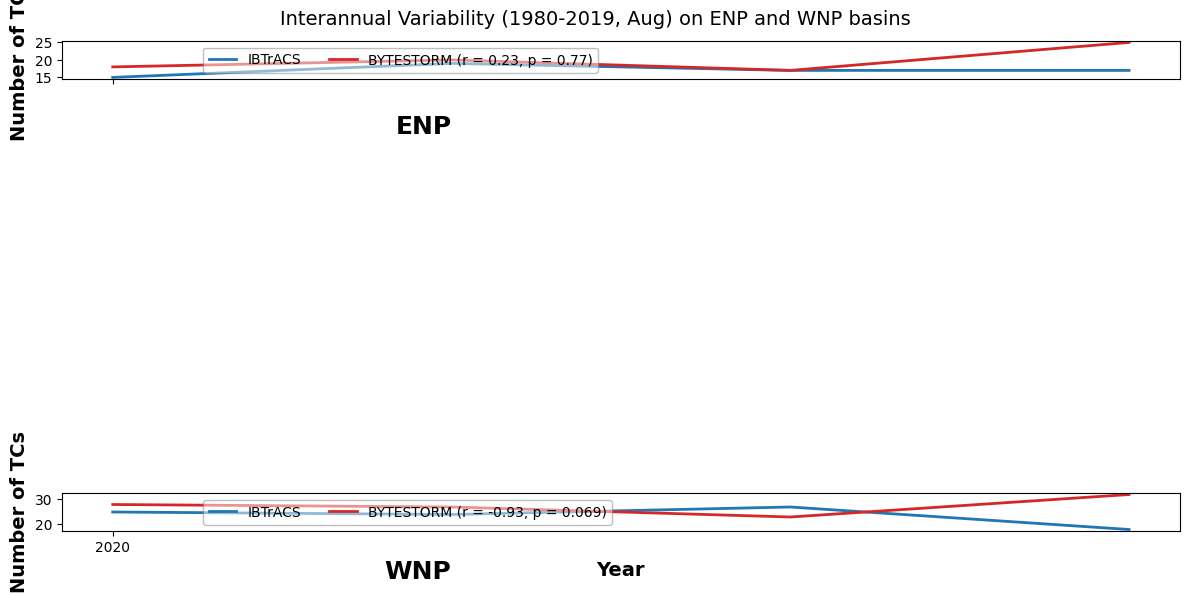

In [49]:
fig, ax = plt.subplots(2, 1, figsize=(12,9), sharex='col')

plt.suptitle(f'Interannual Variability (1980-2019, Aug) on ENP and WNP basins', size=14)

ax[0].plot(np.arange(len(years)), ibtracs_iav_enp, label=f'IBTrACS', linewidth=2.0, color='tab:blue')# , linestyle='dashed')
ax[0].plot(np.arange(len(years)), hybrid_iav_enp, label=f'{our_work_name.upper()} (r = {hybrid_iav_enp_pearsonr_round}, p = {hybrid_iav_enp_pearsonr_signif})', linewidth=2.0, color='tab:red')

ax[0].set_ylabel('Number of TCs', fontdict={'weight':'bold', 'size':'14'})
ax[0].text(1, 1, 'ENP', fontsize=18, weight='bold', color='black', ha='right', va='center')

ax[1].plot(np.arange(len(years)), ibtracs_iav_wnp, label=f'IBTrACS', linewidth=2.0, color='tab:blue')# , linestyle='dashed')
ax[1].plot(np.arange(len(years)), hybrid_iav_wnp, label=f'{our_work_name.upper()} (r = {hybrid_iav_wnp_pearsonr_round}, p = {hybrid_iav_wnp_pearsonr_signif})', linewidth=2.0, color='tab:red')

ax[1].set_xticks(np.arange(0, len(years), 5))
ax[1].set_xticklabels(np.arange(years[0], years[-1], 5))

ax[1].set_xlabel('Year', fontdict={'weight':'bold', 'size':'14'})
ax[1].set_ylabel('Number of TCs', fontdict={'weight':'bold', 'size':'14'})
ax[1].text(1, 1, 'WNP', fontsize=18, weight='bold', color='black', ha='right', va='center')

# set legend
box = ax[0].get_position()
ax[0].set_position([box.x0, box.y0, box.width, box.height])
ax[0].legend(loc='upper left', markerscale=8, edgecolor='gray', framealpha=0.5, ncol=3, bbox_to_anchor=(0.12 ,1.0))

box = ax[1].get_position()
ax[1].set_position([box.x0, box.y0, box.width, box.height])
ax[1].legend(loc='upper left', markerscale=8, edgecolor='gray', framealpha=0.5, ncol=3, bbox_to_anchor=(0.12 ,1.0))

plt.tight_layout()
plt.savefig(os.path.join(out_dir, f'interannual_variability_enp_and_wnp_basins.{file_ext}'), dpi=300) if save_figures else plt.show()
# plt.show()

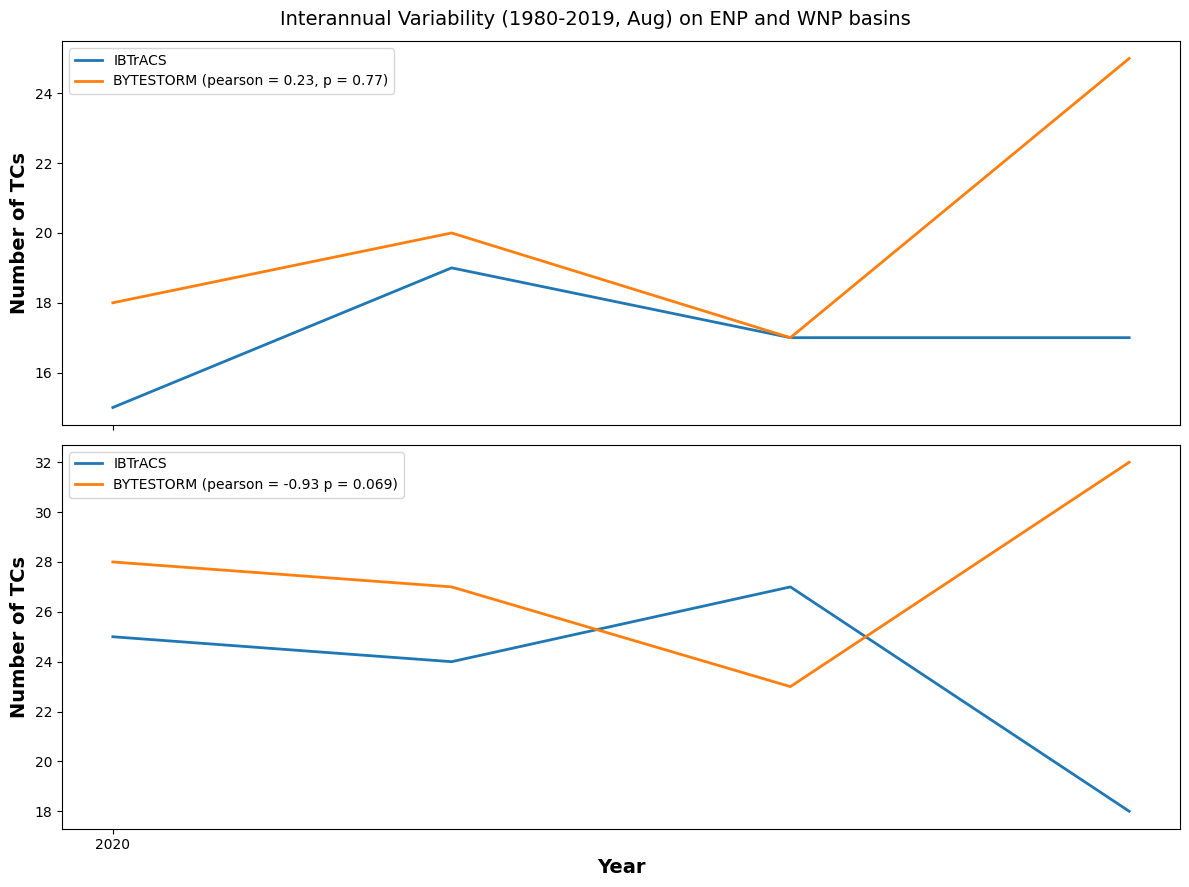

In [50]:
fig, ax = plt.subplots(2, 1, figsize=(12,9), sharex='col')

plt.suptitle(f'Interannual Variability (1980-2019, Aug) on ENP and WNP basins', size=14)

ax[0].plot(np.arange(len(years)), ibtracs_iav_enp, label=f'IBTrACS', linewidth=2.0, color='tab:blue')# , linestyle='dashed')
ax[0].plot(np.arange(len(years)), hybrid_iav_enp, label=f'{our_work_name.upper()} (pearson = {hybrid_iav_enp_pearsonr_round}, p = {hybrid_iav_enp_pearsonr_signif})', linewidth=2.0, color='tab:orange')

ax[0].set_ylabel('Number of TCs', fontdict={'weight':'bold', 'size':'14'})

ax[0].legend()

ax[1].plot(np.arange(len(years)), ibtracs_iav_wnp, label=f'IBTrACS', linewidth=2.0, color='tab:blue')# , linestyle='dashed')
ax[1].plot(np.arange(len(years)), hybrid_iav_wnp, label=f'{our_work_name.upper()} (pearson = {hybrid_iav_wnp_pearsonr_round} p = {hybrid_iav_wnp_pearsonr_signif})', linewidth=2.0, color='tab:orange')

ax[1].set_xticks(np.arange(0, len(years), 5))
ax[1].set_xticklabels(np.arange(years[0], years[-1], 5))

ax[1].set_xlabel('Year', fontdict={'weight':'bold', 'size':'14'})
ax[1].set_ylabel('Number of TCs', fontdict={'weight':'bold', 'size':'14'})

ax[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(out_dir, f'interannual_variability_enp_and_wnp_basin_hybrid_only.{file_ext}'), dpi=300) if save_figures else plt.show()

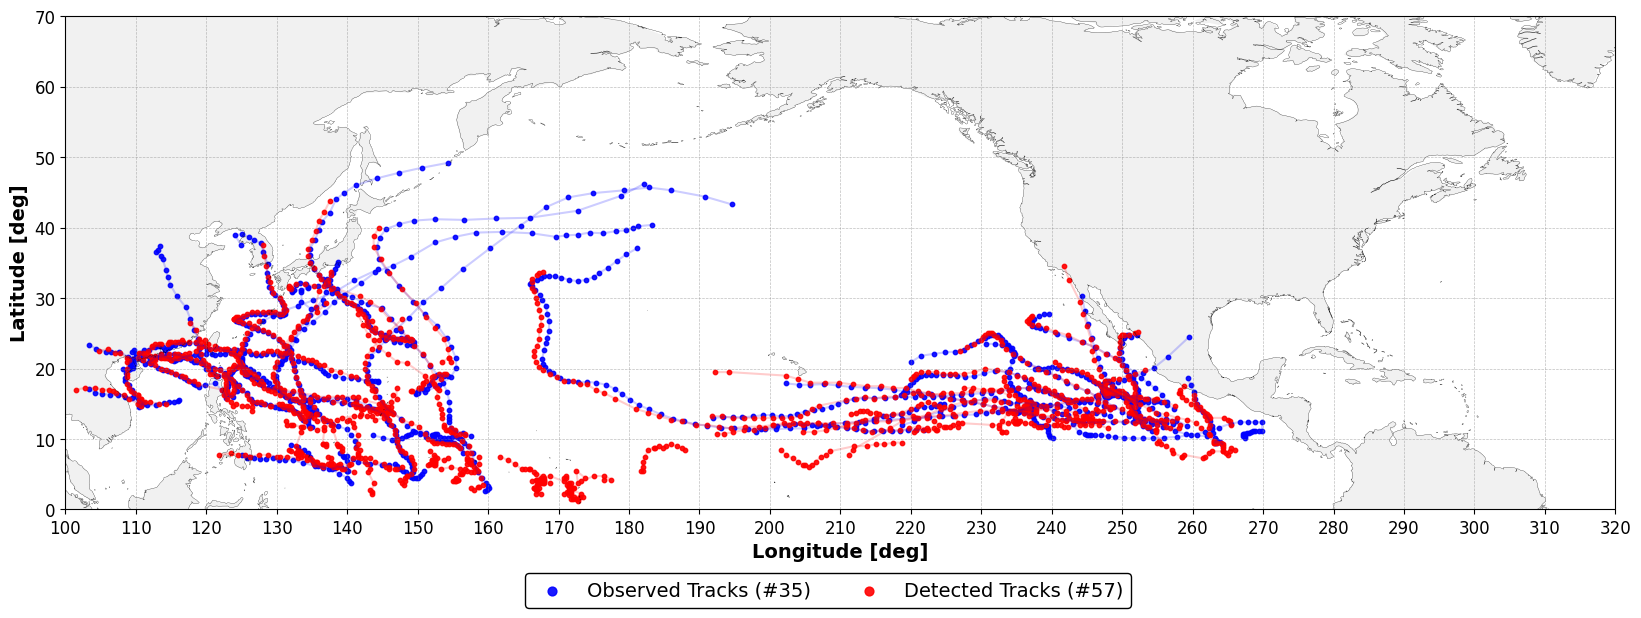

In [51]:
hybrid['lon'] = ((hybrid['lon'] + 360) % 360)
ibtracs['lon'] = ((ibtracs['lon'] + 360) % 360)
track['lon'] = ((track['lon'] + 360) % 360)

year = 2023
plot_tracks(
    hybrid[hybrid['time'].dt.year.isin([year])].rename(columns = {'track_id': 'TRACK_ID', 'lat':'LAT', 'lon': 'LON'}), 
    ibtracs[ibtracs['time'].dt.year.isin([year])].rename(columns = {'track_id': 'TRACK_ID', 'lat':'LAT', 'lon': 'LON'}), 
    lat_range, 
    lon_range, 
    title='', 
    outfile=os.path.join(out_dir, f'plot_tracks_{our_work_name}_{year}.{file_ext}') if save_figures else None)


## De-Trended Interannual Variability

In [52]:
# compute interannual variabilities
ibtracs['year'] = ibtracs['time'].dt.year
hybrid['year'] = hybrid['time'].dt.year

years_df = pd.DataFrame(data={'year':years})

# compute interannual variability
ibtracs_iav_enp_norm = pd.merge(ibtracs[ibtracs['basin']=='ENP'].groupby(by='year')['track_id'].unique().apply(len).reset_index(), years_df, on='year', how='right').fillna(0)['track_id'].to_numpy()
hybrid_iav_enp_norm = pd.merge(hybrid[hybrid['basin']=='ENP'].groupby(by='year')['track_id'].unique().apply(len).reset_index(), years_df, on='year', how='right').fillna(0)['track_id'].to_numpy()

# compute interannual variability
ibtracs_iav_wnp_norm = pd.merge(ibtracs[ibtracs['basin']=='WNP'].groupby(by='year')['track_id'].unique().apply(len).reset_index(), years_df, on='year', how='right').fillna(0)['track_id'].to_numpy()
hybrid_iav_wnp_norm = pd.merge(hybrid[hybrid['basin']=='WNP'].groupby(by='year')['track_id'].unique().apply(len).reset_index(), years_df, on='year', how='right').fillna(0)['track_id'].to_numpy()

x = np.arange(len(years))

# compute the trend
ibtracs_poly1d_fn_enp = np.poly1d(np.polyfit(x, ibtracs_iav_enp_norm, 1))
hybrid_poly1d_fn_enp = np.poly1d(np.polyfit(x, hybrid_iav_enp_norm, 1))

# compute the trend
ibtracs_poly1d_fn_wnp = np.poly1d(np.polyfit(x, ibtracs_iav_wnp_norm, 1))
hybrid_poly1d_fn_wnp = np.poly1d(np.polyfit(x, hybrid_iav_wnp_norm, 1))

# subtract the trend from the variability
ibtracs_iav_enp_norm = ibtracs_iav_enp_norm - ibtracs_poly1d_fn_enp(x)
hybrid_iav_enp_norm = hybrid_iav_enp_norm - hybrid_poly1d_fn_enp(x)

# subtract the trend from the variability
ibtracs_iav_wnp_norm = ibtracs_iav_wnp_norm - ibtracs_poly1d_fn_wnp(x)
hybrid_iav_wnp_norm = hybrid_iav_wnp_norm - hybrid_poly1d_fn_wnp(x)


# compute the pearson correlation coefficient
ibtracs_iav_enp_pearsonr_norm = pearsonr(ibtracs_iav_enp_norm, ibtracs_iav_enp_norm)
hybrid_iav_enp_pearsonr_norm = pearsonr(ibtracs_iav_enp_norm, hybrid_iav_enp_norm)

# get the statistics and round it
ibtracs_iav_enp_pearsonr_round_norm = np.round(ibtracs_iav_enp_pearsonr_norm.statistic, 2)
hybrid_iav_enp_pearsonr_round_norm = np.round(hybrid_iav_enp_pearsonr_norm.statistic, 2)

# get the significance value
ibtracs_iav_enp_pearsonr_signif_norm = signif(ibtracs_iav_enp_pearsonr_norm.pvalue, 2)
hybrid_iav_enp_pearsonr_signif_norm = signif(hybrid_iav_enp_pearsonr_norm.pvalue, 2)

# compute the pearson correlation coefficient
ibtracs_iav_wnp_pearsonr_norm = pearsonr(ibtracs_iav_wnp_norm, ibtracs_iav_wnp_norm)
hybrid_iav_wnp_pearsonr_norm = pearsonr(ibtracs_iav_wnp_norm, hybrid_iav_wnp_norm)

# get the statistics and round it
ibtracs_iav_wnp_pearsonr_round_norm = np.round(ibtracs_iav_wnp_pearsonr_norm.statistic, 2)
hybrid_iav_wnp_pearsonr_round_norm = np.round(hybrid_iav_wnp_pearsonr_norm.statistic, 2)

# get the significance value
ibtracs_iav_wnp_pearsonr_signif_norm = signif(ibtracs_iav_wnp_pearsonr_norm.pvalue, 2)
hybrid_iav_wnp_pearsonr_signif_norm = signif(hybrid_iav_wnp_pearsonr_norm.pvalue, 2)

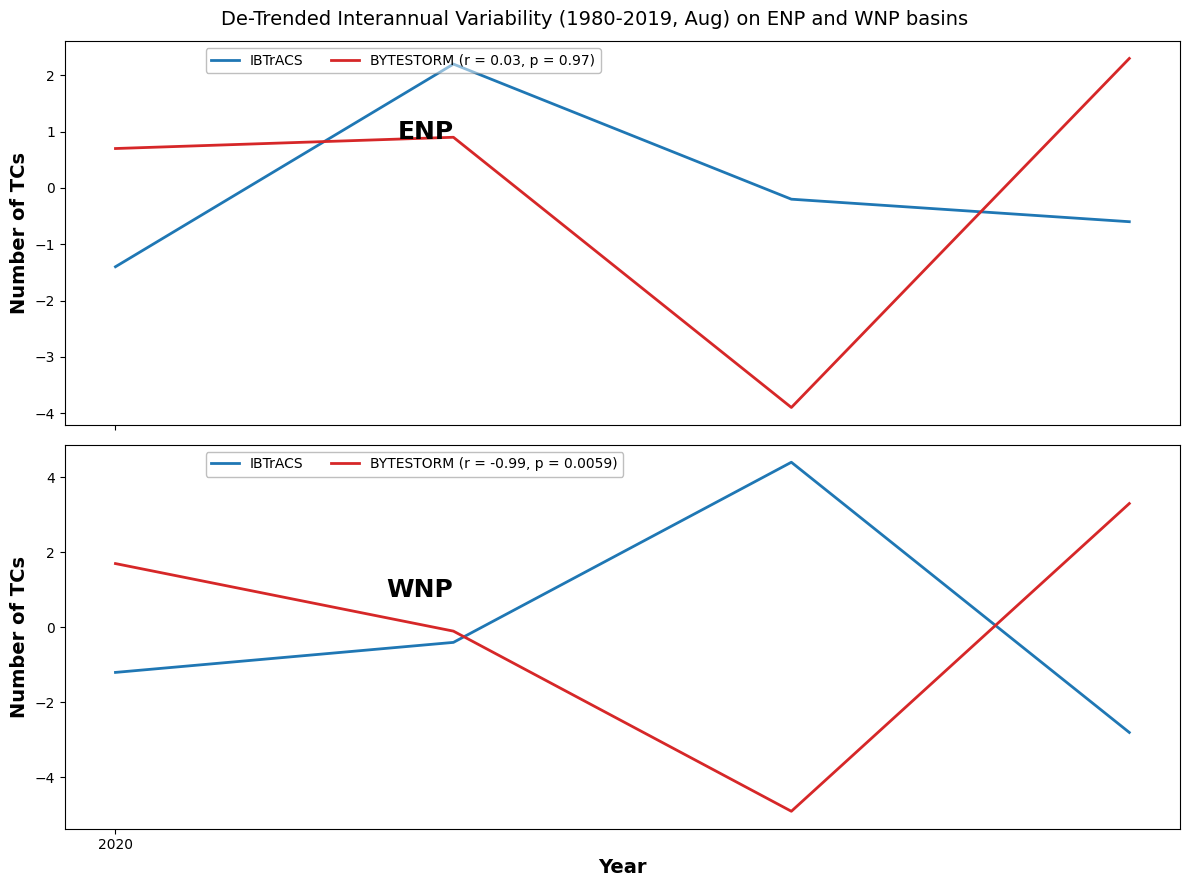

In [53]:
fig, ax = plt.subplots(2, 1, figsize=(12,9), sharex='col')
x = np.arange(len(years))

plt.suptitle(f'De-Trended Interannual Variability (1980-2019, Aug) on ENP and WNP basins', size=14)

ax[0].plot(x, ibtracs_iav_enp_norm, label=f'IBTrACS', linewidth=2.0, color='tab:blue')# , linestyle='dashed')
ax[0].plot(x, hybrid_iav_enp_norm, label=f'{our_work_name.upper()} (r = {hybrid_iav_enp_pearsonr_round_norm}, p = {hybrid_iav_enp_pearsonr_signif_norm})', linewidth=2.0, color='tab:red')

ax[0].set_ylabel('Number of TCs', fontdict={'weight':'bold', 'size':'14'})
ax[0].text(1, 1, 'ENP', fontsize=18, weight='bold', color='black', ha='right', va='center')

ax[1].plot(x, ibtracs_iav_wnp_norm, label=f'IBTrACS', linewidth=2.0, color='tab:blue')# , linestyle='dashed')
ax[1].plot(x, hybrid_iav_wnp_norm, label=f'{our_work_name.upper()} (r = {hybrid_iav_wnp_pearsonr_round_norm}, p = {hybrid_iav_wnp_pearsonr_signif_norm})', linewidth=2.0, color='tab:red')

ax[1].set_xticks(np.arange(0, len(years), 5))
ax[1].set_xticklabels(np.arange(years[0], years[-1], 5))

ax[1].set_xlabel('Year', fontdict={'weight':'bold', 'size':'14'})
ax[1].set_ylabel('Number of TCs', fontdict={'weight':'bold', 'size':'14'})
ax[1].text(1, 1, 'WNP', fontsize=18, weight='bold', color='black', ha='right', va='center')

# set legend
box = ax[0].get_position()
ax[0].set_position([box.x0, box.y0, box.width, box.height])
ax[0].legend(loc='upper left', markerscale=8, edgecolor='gray', framealpha=0.5, ncol=3, bbox_to_anchor=(0.12 ,1.0))

box = ax[1].get_position()
ax[1].set_position([box.x0, box.y0, box.width, box.height])
ax[1].legend(loc='upper left', markerscale=8, edgecolor='gray', framealpha=0.5, ncol=3, bbox_to_anchor=(0.12 ,1.0))

plt.tight_layout()
plt.savefig(os.path.join(out_dir, f'interannual_variability_enp_and_wnp_basins_normalized.{file_ext}'), dpi=300) if save_figures else plt.show()
# plt.show()

# Check Correlation Between Interannual Variabilities

In [54]:
algos = ['ibtracs', 'hybrid']
iav_enps = [ibtracs_iav_enp, hybrid_iav_enp]
iav_wnps = [ibtracs_iav_wnp, hybrid_iav_wnp]

print(f'Correlation between ENP and WNP Basins')
for algo, enp, wnp in zip(algos, iav_enps, iav_wnps):
    pearson_corr = pearsonr(enp, wnp)
    pearson_corr_r = np.round(pearson_corr.statistic, 2)
    pearson_signif = signif(pearson_corr.pvalue, 2)
    print(f'   {algo.upper()} : {pearson_corr_r} ({pearson_signif})')
print()

print(f'Correlation between ENP and WNP Basins (using IBTrACS WNP as reference)')
for algo, enp, _ in zip(algos, iav_enps, iav_wnps):
    pearson_corr = pearsonr(enp, ibtracs_iav_wnp)
    pearson_corr_r = np.round(pearson_corr.statistic, 2)
    pearson_signif = signif(pearson_corr.pvalue, 2)
    print(f'   {algo.upper()} : {pearson_corr_r} ({pearson_signif})')
print()

print(f'Correlation between ENP and WNP Basins (using IBTrACS ENP as reference)')
for algo, _, wnp in zip(algos, iav_enps, iav_wnps):
    pearson_corr = pearsonr(ibtracs_iav_enp, wnp)
    pearson_corr_r = np.round(pearson_corr.statistic, 2)
    pearson_signif = signif(pearson_corr.pvalue, 2)
    print(f'   {algo.upper()} : {pearson_corr_r} ({pearson_signif})')

Correlation between ENP and WNP Basins
   IBTRACS : -0.11 (0.89)
   HYBRID : 0.89 (0.11)

Correlation between ENP and WNP Basins (using IBTrACS WNP as reference)
   IBTRACS : -0.11 (0.89)
   HYBRID : -0.99 (0.0085)

Correlation between ENP and WNP Basins (using IBTrACS ENP as reference)
   IBTRACS : -0.11 (0.89)
   HYBRID : -0.11 (0.89)
